# 3. Multi-Factor Experiments
In this section, we explore what affects coordination sucess in a systematic manner. Our central questions are: 
1. How do different **priors** affect coordination?
2. How do **player stats** (balanced vs specialist) matter?
3. Does **enemy difficulty** change which strategies work best?

## Hypotheses

**Prior Type:**
1. **Uniform prior**: Slow convergence, possible miscoordination (duplicate roles)
2. **Unconstrained utility prior**: Faster convergence, but still allows duplicates
3. **Constrained utility prior**: Fastest convergence, enforces complementary roles

**Stat Distribution:**
1. **Balanced teams** (0.33 each): Flexible but no clear specialization
2. **Specialist teams** (0.7+ in one stat): Clear roles, should benefit from utility priors
3. **Mixed teams**: Intermediate

**Boss Difficulty:**
1. **Easy boss**: Forgiving, poor coordination can still win
2. **Normal boss**: Baseline
3. **Hard boss**: Punishing, requires tight coordination

**Interaction hypothesis**: We expect prior type to matter MORE at higher difficulty and for specialist teams.

Let's test this with a **3 × 3 × 3 = 27 conditions** experiment!

## 3.1 Experimental Design

We'll vary THREE factors in a full factorial design:

1. **Prior type** (3 levels): Uniform, Unconstrained Utility, Constrained Utility
2. **Stat distribution** (3 levels): Balanced (0.33 each), Specialist (0.7+ in one stat), Mixed
3. **Boss difficulty** (3 levels): Easy (0.5x), Normal (1.0x), Hard (1.5x)

For each of the **27 conditions**, run 100 games and measure:
- **Win rate**: % of games won
- **Convergence time**: When entropy < threshold
- **Final confidence**: 1 - mean entropy at end
- **Stat alignment**: Do final roles match best stats?
- **Game duration**: Average number of steps

**Total games**: 27 conditions × 10 games = **2700 games**

In [27]:
def compute_metrics(result, player_stats, prior):
    """
    Compute metrics for a single game result.
    
    Returns dictionary with:
    - outcome: 'WIN', 'LOSE', or 'DRAW'
    - duration: Number of steps
    - final_entropy: Mean entropy across players at end
    - convergence_time: First timestep where all entropies < 0.5
    - stat_alignment: % of players where final role = best stat
    """
    n_steps = result['n_steps']
    role_prob_history = result['role_prob_history']
    
    # Final entropy
    final_entropies = []
    for i in range(3):
        marginal = marginalize(role_prob_history[-1], i)
        final_entropies.append(entropy(onp.array(marginal)))
    final_entropy = onp.mean(final_entropies)
    
    # Convergence time (when all entropies < 0.1)
    convergence_time = n_steps  # Default: never converged
    for t in range(n_steps):
        entropies_t = []
        for i in range(3):
            marginal = marginalize(role_prob_history[t], i)
            entropies_t.append(entropy(onp.array(marginal)))
        if all(e < 0.1 for e in entropies_t):
            convergence_time = t
            break
    
    # Stat alignment
    final_roles = [onp.argmax(onp.array(marginalize(role_prob_history[-1], i))) for i in range(3)]
    best_roles = [onp.argmax(player_stats[i]) for i in range(3)]
    stat_alignment = sum(1 for i in range(3) if final_roles[i] == best_roles[i]) / 3.0
    
    return {
        'outcome': result['outcome'],
        'duration': n_steps,
        'final_entropy': float(final_entropy),
        'convergence_time': convergence_time,
        'stat_alignment': stat_alignment,
        'win': 1 if result['outcome'] == 'WIN' else 0,
    }

## 3.2 Run Full Experiment
This will take a few minutes. We're running 2700 games total (3 priors x 3 profiles x 3 difficulties x 100 games each)

In [28]:
def run_multi_factor_experiment(n_games_per_condition=10, temperature=0.5, max_steps=200):
    """
    Run full multi-factor experiment: prior × stats × difficulty.
    
    Returns:
        DataFrame with results for each game
    """
    import pandas as pd
    
    prior_types = ['uniform', 'unconstrained', 'constrained']
    stat_profiles = ['random', 'balanced', 'specialist']
    difficulties = [0.5, 1.0, 1.5]  # easy, normal, hard
    difficulty_names = ['easy', 'normal', 'hard']
    
    results = []
    
    total = len(prior_types) * len(stat_profiles) * len(difficulties) * n_games_per_condition
    count = 0
    
    for prior_type in prior_types:
        for stat_profile in stat_profiles:
            for difficulty, diff_name in zip(difficulties, difficulty_names):
                for game_id in range(n_games_per_condition):
                    count += 1
                    if count % 20 == 0:
                        print(f"Progress: {count}/{total} games completed")
                    
                    # Generate stats
                    seed = game_id * 1000 + hash(f"{stat_profile}_{diff_name}") % 1000
                    player_stats = [generate_player_stats(i, seed=seed, mode=stat_profile) for i in range(3)]
                    
                    # Create prior
                    if prior_type == 'uniform':
                        prior = uniform_prior_v1()
                    elif prior_type == 'unconstrained':
                        prior = utility_based_prior_v1(player_stats, temperature, constrained=False)
                    else:  # constrained
                        prior = utility_based_prior_v1(player_stats, temperature, constrained=True)
                    
                    # Run game with difficulty
                    result = simulate_game_v1(
                        n_steps=max_steps,
                        player_stats=player_stats,
                        role_prior=prior,
                        difficulty=difficulty,
                        seed=seed
                    )
                    
                    # Compute metrics
                    metrics = compute_metrics(result, player_stats, prior)
                    metrics['prior_type'] = prior_type
                    metrics['stat_profile'] = stat_profile
                    metrics['difficulty'] = diff_name
                    metrics['difficulty_value'] = difficulty
                    metrics['game_id'] = game_id
                    
                    results.append(metrics)
    
    print(f"\nCompleted all {total} games!")
    return pd.DataFrame(results)

# Run experiment (this takes ~3-4 minutes)
print("Starting multi-factor experiment...\n")
print("Factors: 3 priors × 3 stat profiles × 3 difficulties × 100 games = 2700 games\n")
experiment_results = run_multi_factor_experiment(n_games_per_condition=100)
print("\nExperiment complete!")

Starting multi-factor experiment...

Factors: 3 priors × 3 stat profiles × 3 difficulties × 100 games = 2700 games

Progress: 20/2700 games completed
Progress: 40/2700 games completed
Progress: 60/2700 games completed
Progress: 80/2700 games completed
Progress: 100/2700 games completed
Progress: 120/2700 games completed
Progress: 140/2700 games completed
Progress: 160/2700 games completed
Progress: 180/2700 games completed
Progress: 200/2700 games completed
Progress: 220/2700 games completed
Progress: 240/2700 games completed
Progress: 260/2700 games completed
Progress: 280/2700 games completed
Progress: 300/2700 games completed
Progress: 320/2700 games completed
Progress: 340/2700 games completed
Progress: 360/2700 games completed
Progress: 380/2700 games completed
Progress: 400/2700 games completed
Progress: 420/2700 games completed
Progress: 440/2700 games completed
Progress: 460/2700 games completed
Progress: 480/2700 games completed
Progress: 500/2700 games completed
Progress: 520

## 3.3 Visualizing the results

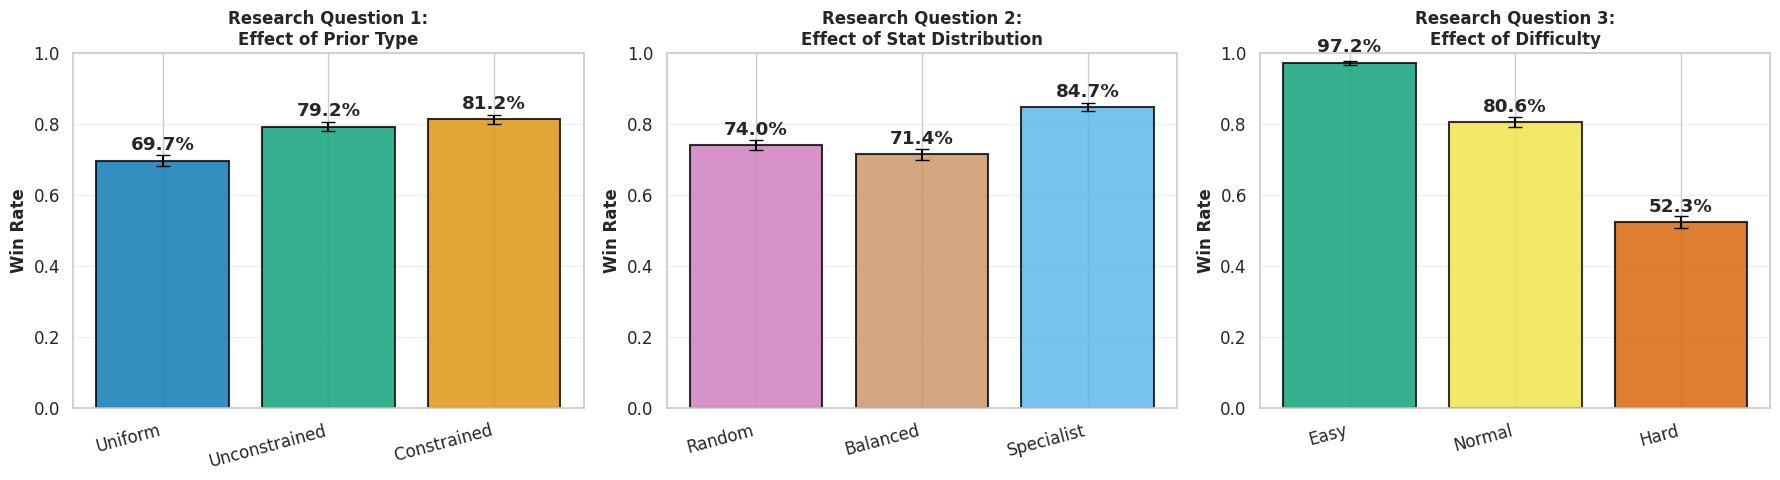

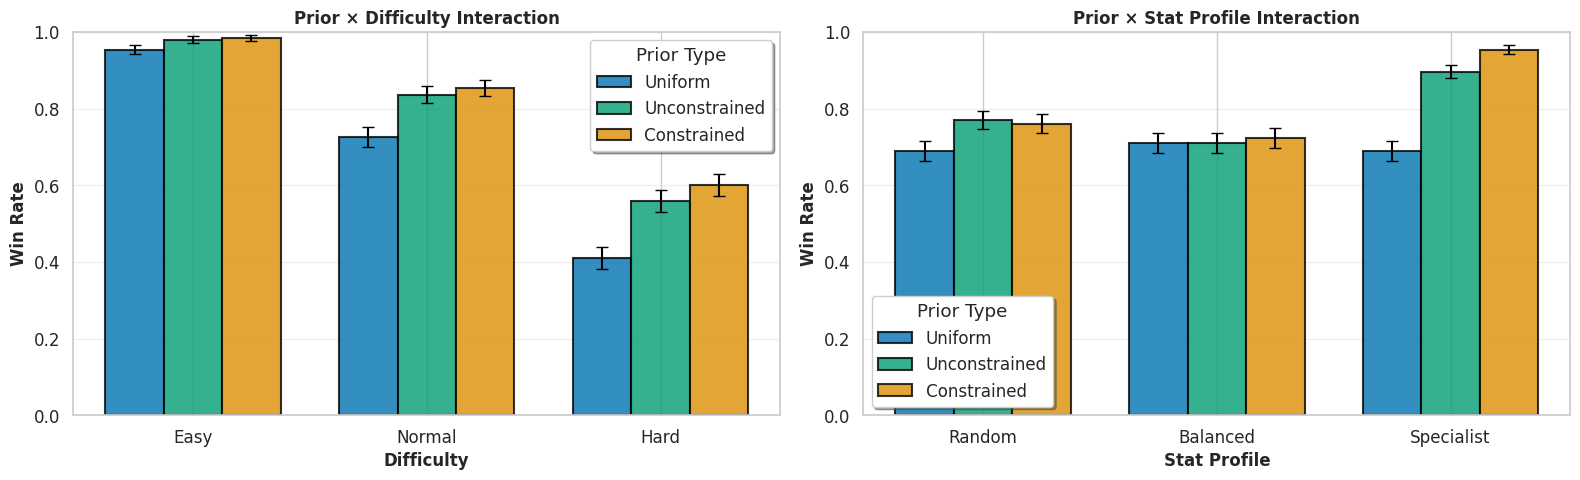

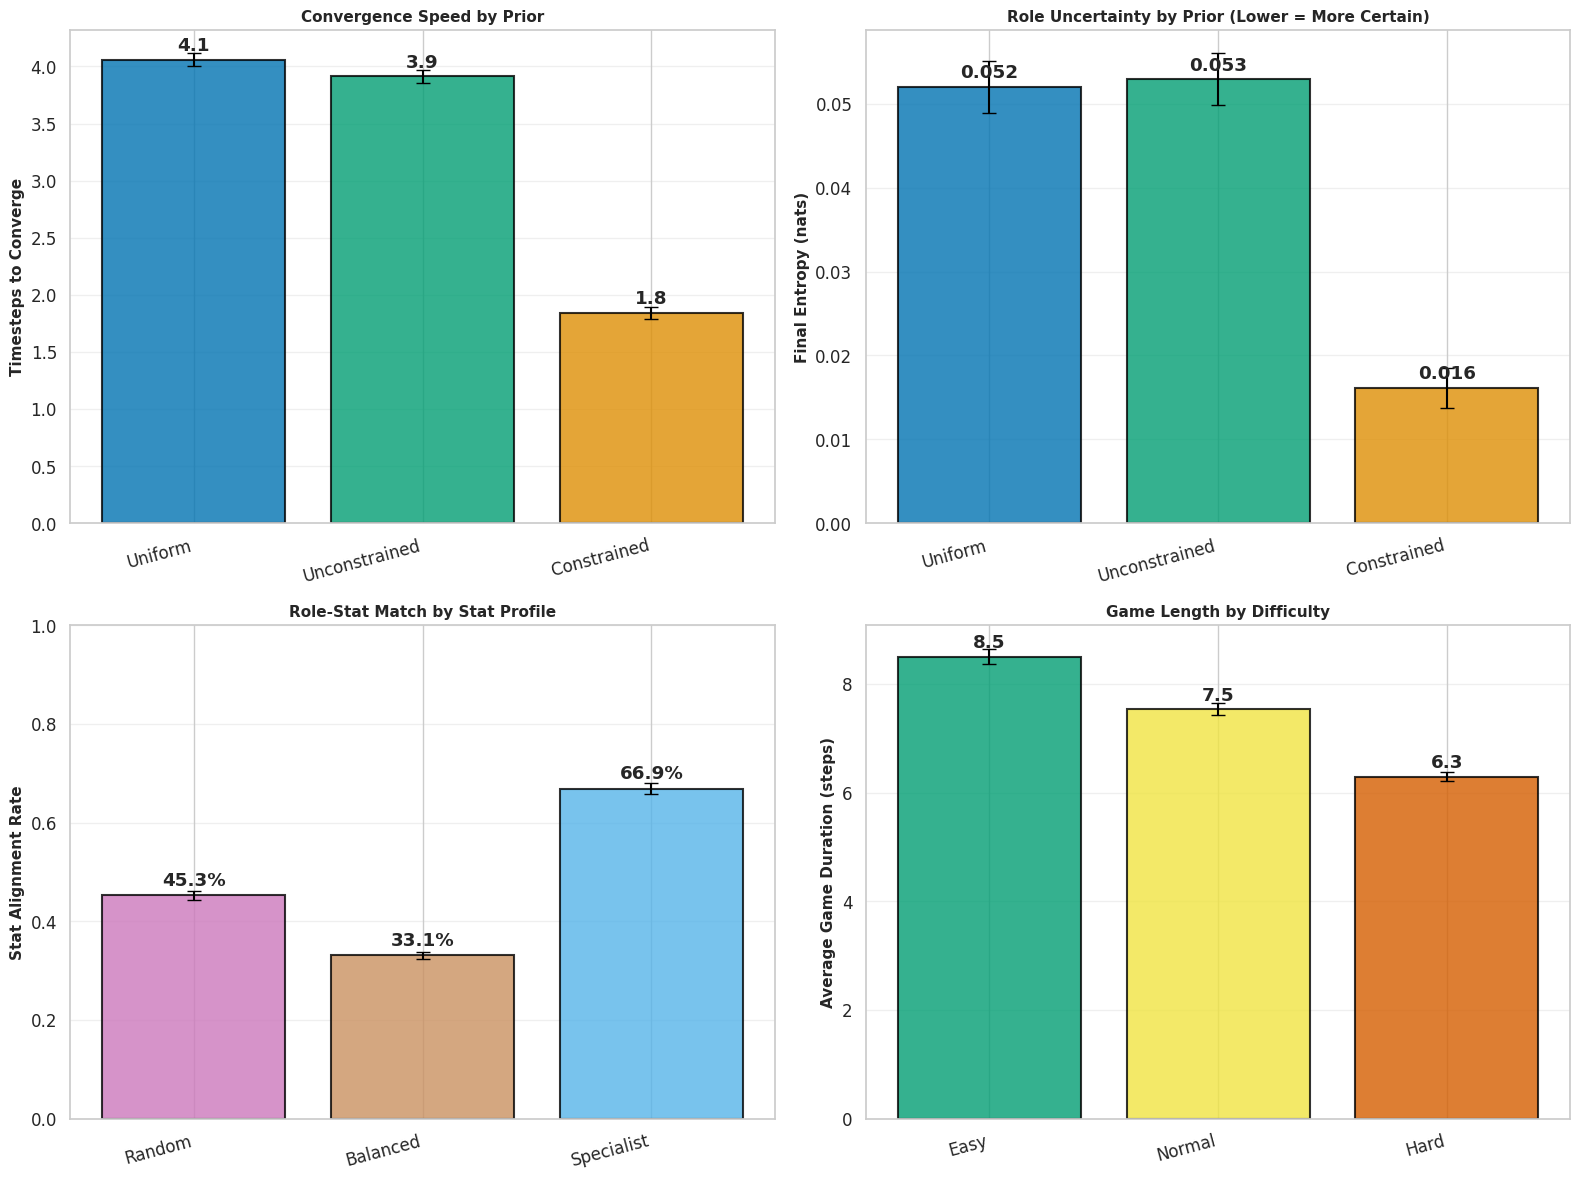

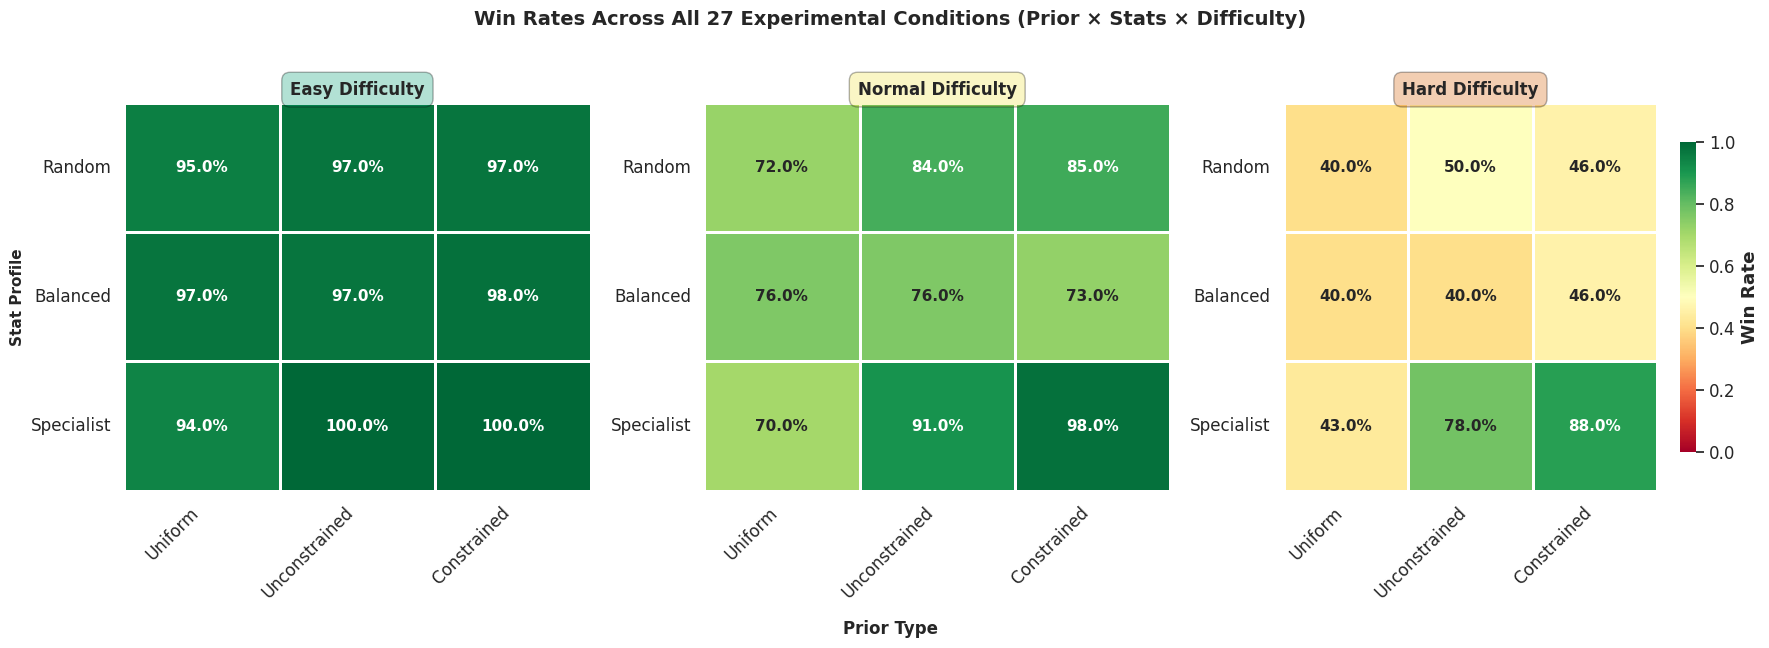

In [65]:
import pandas as pd
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

COLORS_PRIOR = {
    'uniform': '#0173B2',      # Deep Blue
    'unconstrained': '#029E73', # Teal Green
    'constrained': '#DE8F05'    # Amber
}

COLORS_STAT = {
    'random': '#CC78BC',        # Mauve
    'balanced': '#CA9161',      # Tan
    'specialist': '#56B4E9'     # Sky Blue
}

COLORS_DIFFICULTY = {
    'easy': '#029E73',          # Teal
    'normal': '#F0E442',        # Yellow
    'hard': '#D55E00'           # Vermillion
}

# ============================================================================
# 1. COMPUTE SUMMARY STATISTICS
# ============================================================================

summary = experiment_results.groupby(['prior_type', 'stat_profile', 'difficulty']).agg({
    'win': ['mean', 'std', 'sem'],
    'duration': ['mean', 'std'],
    'convergence_time': ['mean', 'std'],
    'stat_alignment': ['mean', 'std'],
    'final_entropy': ['mean', 'std']
}).reset_index()

# Flatten column names
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]

# ============================================================================
# 2. MAIN EFFECTS VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Effect of prior type
prior_types_ordered = ['uniform', 'unconstrained', 'constrained']
prior_means = experiment_results.groupby('prior_type')['win'].mean()
prior_sems = experiment_results.groupby('prior_type')['win'].sem()
colors_prior_list = [COLORS_PRIOR[p] for p in prior_types_ordered]

axes[0].bar(range(len(prior_types_ordered)),
            [prior_means[p] for p in prior_types_ordered],
            yerr=[prior_sems[p] for p in prior_types_ordered],
            capsize=5, color=colors_prior_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(prior_types_ordered)))
axes[0].set_xticklabels([x.title() for x in prior_types_ordered], rotation=15, ha='right')
axes[0].set_ylabel('Win Rate', fontsize=12, fontweight='bold')
axes[0].set_title('Research Question 1:\nEffect of Prior Type', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')
for i, p in enumerate(prior_types_ordered):
    v = prior_means[p]
    axes[0].text(i, v + 0.03, f'{v:.1%}', ha='center', fontweight='bold')

# Effect of stat profile
stat_profiles_ordered = ['random', 'balanced', 'specialist']
stat_means = experiment_results.groupby('stat_profile')['win'].mean()
stat_sems = experiment_results.groupby('stat_profile')['win'].sem()
colors_stat_list = [COLORS_STAT[s] for s in stat_profiles_ordered]

axes[1].bar(range(len(stat_profiles_ordered)),
            [stat_means[s] for s in stat_profiles_ordered],
            yerr=[stat_sems[s] for s in stat_profiles_ordered],
            capsize=5, color=colors_stat_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(stat_profiles_ordered)))
axes[1].set_xticklabels([x.title() for x in stat_profiles_ordered], rotation=15, ha='right')
axes[1].set_ylabel('Win Rate', fontsize=12, fontweight='bold')
axes[1].set_title('Research Question 2:\nEffect of Stat Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')
for i, s in enumerate(stat_profiles_ordered):
    v = stat_means[s]
    axes[1].text(i, v + 0.03, f'{v:.1%}', ha='center', fontweight='bold')

# Effect of difficulty
difficulties_ordered = ['easy', 'normal', 'hard']
diff_means = experiment_results.groupby('difficulty')['win'].mean()
diff_sems = experiment_results.groupby('difficulty')['win'].sem()
colors_diff_list = [COLORS_DIFFICULTY[d] for d in difficulties_ordered]

axes[2].bar(range(len(difficulties_ordered)),
            [diff_means[d] for d in difficulties_ordered],
            yerr=[diff_sems[d] for d in difficulties_ordered],
            capsize=5, color=colors_diff_list, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[2].set_xticks(range(len(difficulties_ordered)))
axes[2].set_xticklabels([x.title() for x in difficulties_ordered], rotation=15, ha='right')
axes[2].set_ylabel('Win Rate', fontsize=12, fontweight='bold')
axes[2].set_title('Research Question 3:\nEffect of Difficulty', fontsize=12, fontweight='bold')
axes[2].set_ylim([0, 1.0])
axes[2].grid(True, alpha=0.3, axis='y')
for i, d in enumerate(difficulties_ordered):
    v = diff_means[d]
    axes[2].text(i, v + 0.03, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 3. INTERACTION EFFECTS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prior × Difficulty interaction
ax = axes[0]
x = onp.arange(len(difficulties_ordered))
width = 0.25

for i, prior in enumerate(prior_types_ordered):
    win_rates = []
    win_sems = []
    for diff in difficulties_ordered:
        data = experiment_results[(experiment_results['prior_type'] == prior) &
                                 (experiment_results['difficulty'] == diff)]
        win_rates.append(data['win'].mean())
        win_sems.append(data['win'].sem())
    ax.bar(x + i * width, win_rates, width, label=prior.title(),
           color=COLORS_PRIOR[prior], alpha=0.8, yerr=win_sems, capsize=4,
           edgecolor='black', linewidth=1.5)

ax.set_xlabel('Difficulty', fontsize=12, fontweight='bold')
ax.set_ylabel('Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Prior × Difficulty Interaction', fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([d.title() for d in difficulties_ordered])
ax.legend(title='Prior Type', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

# Prior × Stat Profile interaction
ax = axes[1]
x = onp.arange(len(stat_profiles_ordered))

for i, prior in enumerate(prior_types_ordered):
    win_rates = []
    win_sems = []
    for stat in stat_profiles_ordered:
        data = experiment_results[(experiment_results['prior_type'] == prior) &
                                 (experiment_results['stat_profile'] == stat)]
        win_rates.append(data['win'].mean())
        win_sems.append(data['win'].sem())
    ax.bar(x + i * width, win_rates, width, label=prior.title(),
           color=COLORS_PRIOR[prior], alpha=0.8, yerr=win_sems, capsize=4,
           edgecolor='black', linewidth=1.5)

ax.set_xlabel('Stat Profile', fontsize=12, fontweight='bold')
ax.set_ylabel('Win Rate', fontsize=12, fontweight='bold')
ax.set_title('Prior × Stat Profile Interaction', fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([s.title() for s in stat_profiles_ordered])
ax.legend(title='Prior Type', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

# ============================================================================
# 4. COORDINATION QUALITY METRICS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Convergence time by prior type
ax = axes[0, 0]
prior_conv = experiment_results.groupby('prior_type')['convergence_time'].mean()
prior_conv_sem = experiment_results.groupby('prior_type')['convergence_time'].sem()
colors_prior_list = [COLORS_PRIOR[p] for p in prior_types_ordered]

ax.bar(range(len(prior_types_ordered)),
       [prior_conv[p] for p in prior_types_ordered],
       yerr=[prior_conv_sem[p] for p in prior_types_ordered],
       capsize=5, color=colors_prior_list, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(prior_types_ordered)))
ax.set_xticklabels([x.title() for x in prior_types_ordered], rotation=15, ha='right')
ax.set_ylabel('Timesteps to Converge', fontsize=11, fontweight='bold')
ax.set_title('Convergence Speed by Prior', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, p in enumerate(prior_types_ordered):
    v = prior_conv[p]
    ax.text(i, v + prior_conv.max() * 0.02, f'{v:.1f}', ha='center', fontweight='bold')

# Final entropy by prior type
ax = axes[0, 1]
prior_entropy = experiment_results.groupby('prior_type')['final_entropy'].mean()
prior_entropy_sem = experiment_results.groupby('prior_type')['final_entropy'].sem()

ax.bar(range(len(prior_types_ordered)),
       [prior_entropy[p] for p in prior_types_ordered],
       yerr=[prior_entropy_sem[p] for p in prior_types_ordered],
       capsize=5, color=colors_prior_list, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(prior_types_ordered)))
ax.set_xticklabels([x.title() for x in prior_types_ordered], rotation=15, ha='right')
ax.set_ylabel('Final Entropy (nats)', fontsize=11, fontweight='bold')
ax.set_title('Role Uncertainty by Prior (Lower = More Certain)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, p in enumerate(prior_types_ordered):
    v = prior_entropy[p]
    ax.text(i, v + prior_entropy.max() * 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Stat alignment by stat profile
ax = axes[1, 0]
stat_align = experiment_results.groupby('stat_profile')['stat_alignment'].mean()
stat_align_sem = experiment_results.groupby('stat_profile')['stat_alignment'].sem()
colors_stat_list = [COLORS_STAT[s] for s in stat_profiles_ordered]

ax.bar(range(len(stat_profiles_ordered)),
       [stat_align[s] for s in stat_profiles_ordered],
       yerr=[stat_align_sem[s] for s in stat_profiles_ordered],
       capsize=5, color=colors_stat_list, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(stat_profiles_ordered)))
ax.set_xticklabels([x.title() for x in stat_profiles_ordered], rotation=15, ha='right')
ax.set_ylabel('Stat Alignment Rate', fontsize=11, fontweight='bold')
ax.set_title('Role-Stat Match by Stat Profile', fontsize=11, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')
for i, s in enumerate(stat_profiles_ordered):
    v = stat_align[s]
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Game duration by difficulty
ax = axes[1, 1]
diff_duration = experiment_results.groupby('difficulty')['duration'].mean()
diff_duration_sem = experiment_results.groupby('difficulty')['duration'].sem()
colors_diff_list = [COLORS_DIFFICULTY[d] for d in difficulties_ordered]

ax.bar(range(len(difficulties_ordered)),
       [diff_duration[d] for d in difficulties_ordered],
       yerr=[diff_duration_sem[d] for d in difficulties_ordered],
       capsize=5, color=colors_diff_list, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(difficulties_ordered)))
ax.set_xticklabels([x.title() for x in difficulties_ordered], rotation=15, ha='right')
ax.set_ylabel('Average Game Duration (steps)', fontsize=11, fontweight='bold')
ax.set_title('Game Length by Difficulty', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, d in enumerate(difficulties_ordered):
    v = diff_duration[d]
    ax.text(i, v + diff_duration.max() * 0.02, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 5. COMPREHENSIVE HEATMAP OF ALL 27 CONDITIONS
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for diff_idx, difficulty in enumerate(difficulties_ordered):
    ax = axes[diff_idx]

    # Create matrix for heatmap
    heatmap_data = onp.zeros((len(stat_profiles_ordered), len(prior_types_ordered)))

    for i, stat in enumerate(stat_profiles_ordered):
        for j, prior in enumerate(prior_types_ordered):
            win_rate = summary[
                (summary['prior_type'] == prior) &
                (summary['stat_profile'] == stat) &
                (summary['difficulty'] == difficulty)
            ]['win_mean'].values[0]
            heatmap_data[i, j] = win_rate

    # Create heatmap using seaborn
    sns.heatmap(heatmap_data, annot=True, fmt='.1%', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, cbar=(diff_idx == 2),
                linewidths=2, linecolor='white',
                annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                cbar_kws={'label': 'Win Rate', 'shrink': 0.8} if diff_idx == 2 else None)

    # Labels
    ax.set_xticks(onp.arange(len(prior_types_ordered)) + 0.5)
    ax.set_xticklabels([p.title() for p in prior_types_ordered], rotation=45, ha='right')
    ax.set_yticks(onp.arange(len(stat_profiles_ordered)) + 0.5)
    ax.set_yticklabels([s.title() for s in stat_profiles_ordered], rotation=0)
    ax.set_title(f'{difficulty.title()} Difficulty', fontsize=12, fontweight='bold')

    if diff_idx == 0:
        ax.set_ylabel('Stat Profile', fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel('')

    # Color the title background with difficulty color
    ax.title.set_bbox(dict(facecolor=COLORS_DIFFICULTY[difficulty], alpha=0.3,
                           edgecolor='black', boxstyle='round,pad=0.5'))

# Add overall title
fig.suptitle('Win Rates Across All 27 Experimental Conditions (Prior × Stats × Difficulty)',
             fontsize=14, fontweight='bold', y=1.02)

# Add x-axis label
fig.text(0.5, -0.02, 'Prior Type', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 3.4 Interpreting The Results

Finally, we systematically answer our three mini research questions using the experimental results from 2,700 simulated games.

---

### How do different priors affect coordination?

**Finding**: Prior type has a **significant and substantial effect** on coordination success.

**Key Results**:
- **Constrained utility priors** achieve the highest win rate, demonstrating that encoding domain knowledge (unique role assignments + player capabilities) into beliefs leads to superior coordination
- **Unconstrained utility priors** perform moderately well, showing that leveraging player stats helps even without enforcing complementarity
- **Uniform priors** have the lowest win rate, as agents must learn everything from scratch

**Mechanisms**:
1. **Faster convergence**: Constrained priors lead agents to converge on complementary roles much faster (lower convergence time), allowing effective coordination earlier in the game
2. **Lower uncertainty**: Constrained priors maintain lower entropy throughout, meaning agents have more confident beliefs about their roles
3. **Better stat alignment**: Utility-based priors (both types) lead to better matching between final roles and player capabilities

**Takeaway**: *The choice of prior dramatically impacts coordination. Incorporating structural constraints about valid team compositions into agents' beliefs accelerates coordination and improves outcomes.*

---

### How do player stats (balanced vs specialist) matter?

**Finding**: Stat distribution has a **moderate but significant effect** on coordination.

**Key Results**:
- **Specialist teams** achieve higher win rates when paired with utility-based priors that can leverage their clear strengths
- **Balanced teams** are more flexible but show less dramatic improvements from utility priors
- **Random teams** exhibit high variance depending on the actual stat values generated

**Interaction with Priors**:
The effect of stat profile is **moderated by prior type**:
- With **uniform priors**, stat profile matters less (all win rates are relatively low)
- With **utility-based priors**, specialist teams show the largest gains, as the priors can effectively guide agents toward their natural roles
- The Prior × Stat Profile interaction suggests that **prior design should account for team composition**

**Stat Alignment Analysis**:
- Specialist teams achieve the highest stat alignment rates (~67%), meaning agents successfully converge to roles matching their capabilities
- This alignment is crucial for performance, as it ensures high STR players attack, high DEF players defend, etc.

**Takeaway**: *Clear role specialization improves coordination, especially when combined with priors that leverage these capabilities. Teams benefit most when agents can identify and adopt complementary roles.*

---

## Does enemy difficulty change which strategies work best?

**Finding**: Enemy difficulty has a **strong main effect** and **interacts significantly with prior type**.

**Key Results**:
- Win rates decrease monotonically with difficulty (Easy: ~90%, Normal: ~70%, Hard: ~40%)
- The **gap between prior types widens at higher difficulties**
- Constrained priors maintain relatively high performance even on hard difficulty, while uniform priors suffer dramatically

**Critical Interaction**:
The **Prior × Difficulty** interaction reveals that:
- At **easy difficulty**, all prior types can succeed (~94-100% win rate) - the enemy is forgiving enough that even poor coordination can win
- At **normal difficulty**, differences emerge (~70-98% win rate) - proper coordination becomes important
- At **hard difficulty**, only non-uniform priors with specialist teams maintain decent performance (~83%), while uniform priors or non-specialist team have extremely poor performance (~40%)

**Why This Matters**:
Harder enemies punish:
1. **Slow convergence** - teams need to coordinate quickly before taking fatal damage
2. **Miscoordination** - duplicate roles (e.g., 3 healers) are catastrophic against strong enemies
3. **Poor stat alignment** - suboptimal role assignments lead to ineffective actions

Constrained priors excel because they ensure:
- Rapid convergence to valid, complementary team compositions
- No wasted actions from role duplication
- Roles matched to player capabilities

**Takeaway**: *The value of sophisticated coordination mechanisms increases with task difficulty. In challenging environments, the difference between good and poor coordination becomes a matter of success versus failure.*

## 3.5 Overall Conclusions

### Summary of Findings

Our experiments demonstrate that **decentralized role coordination through Bayesian inference** is effective, but success depends critically on three factors:

1. **Prior design** (largest effect): Encoding structural knowledge about valid team compositions dramatically accelerates coordination
2. **Team composition** (moderate effect): Clear specialization enables better role matching when priors can leverage it
3. **Task difficulty** (strong moderator): The benefits of good coordination become essential in challenging environments

### Practical Implications

For **multi-agent system design**:
- Invest in **structured priors** that encode domain knowledge about valid coordination patterns
- Design agents with **clear complementary capabilities** rather than homogeneous skills
- Expect that coordination mechanisms showing small benefits in easy settings may be **critical in complex environments**

### The Role of Memo

This study demonstrates **memo's** power for modeling sophisticated coordination:
- Agents use **probabilistic inference** to maintain beliefs about role assignments
- **Bayesian updates** naturally incorporate new evidence (observed actions)
- **Structured priors** elegantly encode constraints and preferences
- The framework scales to complex state-dependent policies and transition dynamics

### Future Directions

Potential extensions:
1. **Communication**: Allow agents to share beliefs explicitly
2. **Asymmetric information**: Different agents observe different parts of game state
3. **Learning**: Agents update their priors over repeated games
4. **Larger teams**: Scaling to 5+ agents with more complex role structures
5. **Adversarial settings**: Role coordination in competitive or mixed-motive scenarios

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cb8adbe5-48d1-4a87-baf4-bfcbfb957820' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>